<a href="https://colab.research.google.com/github/burarama/AI-Clinical-Respiratory-Assistant/blob/main/respiratory_disease_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Respiratory Diagnostics: Core Training and Feature Extraction Pipeline
This notebook handles the end-to-end development cycle for building a multi-class respiratory condition predictor. It implements a robust machine learning Stacking Ensemble Classifier and binds it with a local LLM environment for conversational symptom mining.

### Step 1: Ingesting Datasets and Standardizing Core Variables
We start by loading our tabular clinical features, extracting symptom dimensions, and generating stratified training and evaluation data splits.


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Load your dataset
data = pd.read_csv("Optimized_Respiratory_Data.csv")

# Separate features (symptoms) and target (disease)
X = data.drop("diseases", axis=1)   # all symptom columns
y = data["diseases"]                # disease label column

# Define feature_names globally
feature_names = X.columns.tolist()

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train the model
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train, y_train)


FileNotFoundError: [Errno 2] No such file or directory: 'Optimized_Respiratory_Data.csv'

### Step 2: Training a Baseline Decision Tree Classifier
To establish an entry-level performance metric, we train a single balanced Decision Tree with restricted depth to prevent immediate overfitting and analyze feature node rules.


In [ ]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.7842170160295932


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print("Cross-validation accuracy:", scores.mean())


Cross-validation accuracy: 0.7756624195095219


### Step 3: Exploratory Interpretation & Tree Node Layouts
We visualize feature importance bar metrics and structural node splits to verify how individual symptoms influence raw entropy branches.


In [2]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importance")
plt.ylabel("Symptoms")
plt.title("Symptom Importance in Disease Prediction")
plt.show()


ModuleNotFoundError: No module named 'matplotlib'

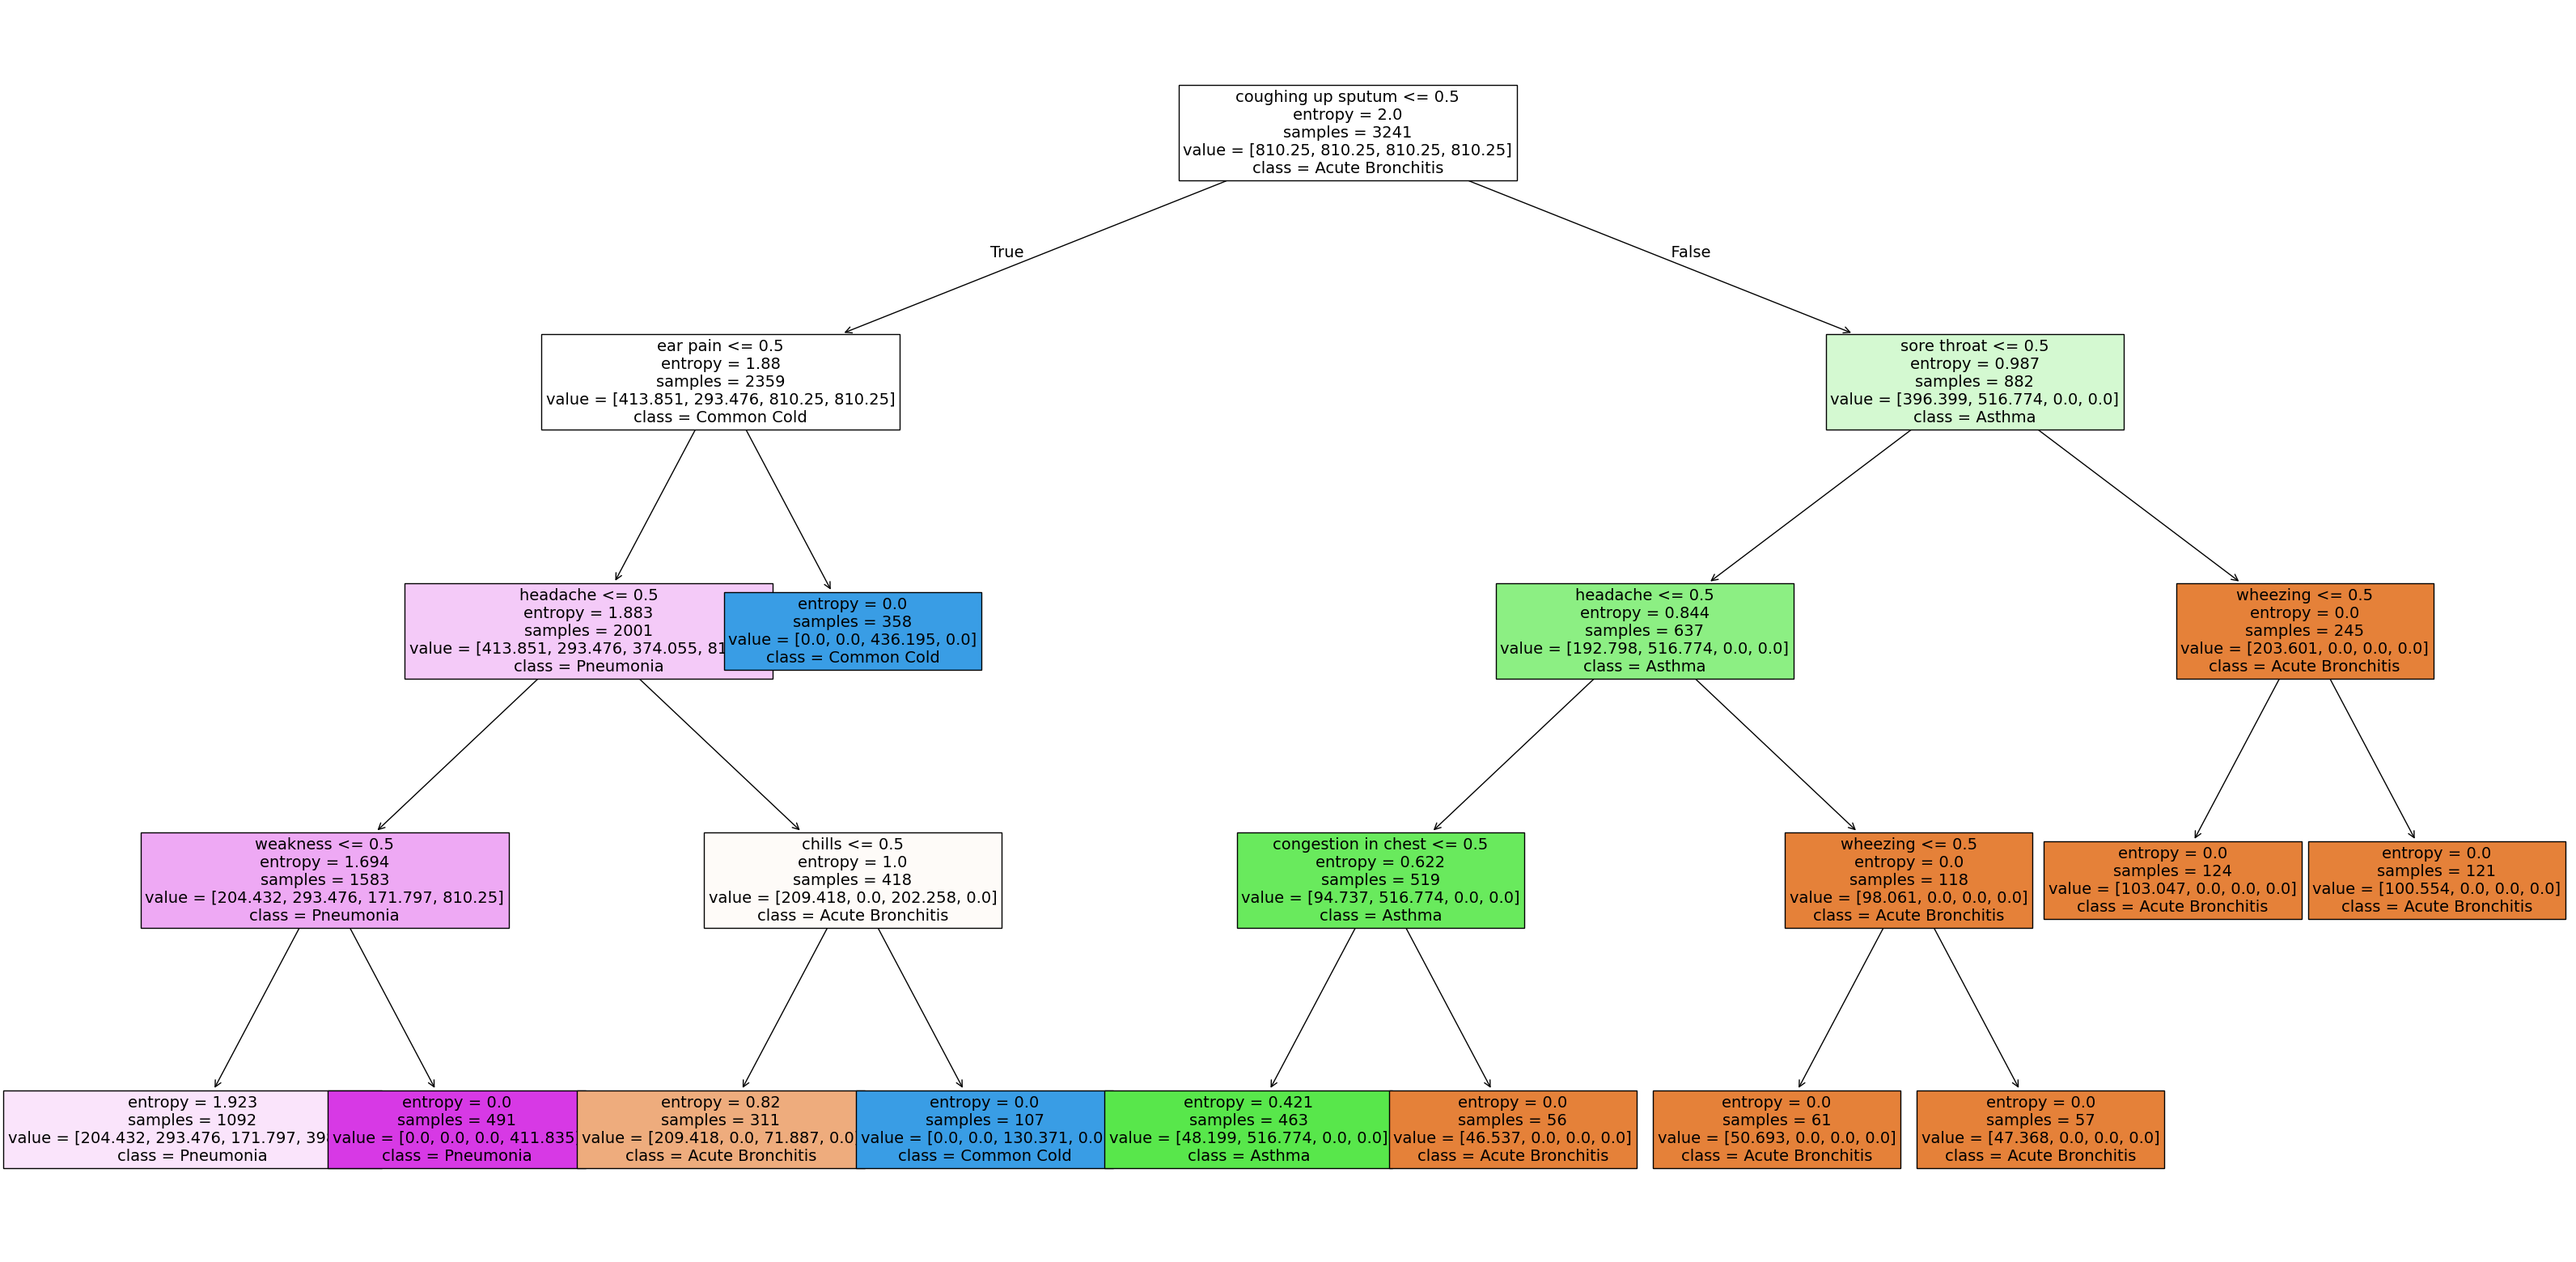

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(40,20))
plot_tree(model, feature_names=X.columns, class_names=model.classes_, filled=True, fontsize=14)
plt.show()


In [3]:
from sklearn.tree import export_graphviz
export_graphviz(model, out_file="tree.dot",
                feature_names=X.columns,
                class_names=model.classes_,
                filled=True)
!dot -Tpng tree.dot -o tree.png


NameError: name 'model' is not defined

### Step 4: Training Advanced Boosting and Bagging Classifiers
To overcome baseline tree limitations, we introduce independent ensemble models:
1. **Random Forest**: Aggregates decoupled tree paths to lower overall variance.
2. **Gradient Boosting**: Optimizes residual step weights to minimize system bias.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    min_samples_leaf= 5
)
rf_model.fit(X_train, y_train)

from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf_model, X, y, cv=5)
print("Random Forest CV accuracy:", scores.mean())


Random Forest CV accuracy: 0.8938777001415719


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
gb_model.fit(X_train, y_train)

from sklearn.model_selection import cross_val_score
scores = cross_val_score(gb_model, X, y, cv=5)
print("Gradient Boosting CV accuracy:", scores.mean())

Gradient Boosting CV accuracy: 0.8825266779315278


In [ ]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Base learners (keep your best Random Forest params)
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

# Meta learner (final combiner)
meta = LogisticRegression(max_iter=1000)

# Stacking ensemble
stack_model = StackingClassifier(
    estimators=[('rf', rf), ('gb', gb)],
    final_estimator=meta,
    cv=5
)

# Train and evaluate
stack_model.fit(X_train, y_train)
scores = cross_val_score(stack_model, X, y, cv=5, scoring='f1_macro')
print("Stacking CV F1:", scores.mean())


Stacking CV F1: 0.9043547212239271


### Step 5: Constructing the Stacking Meta-Learner Architecture
We create a unified **StackingClassifier** combining our structural models (`RandomForest`, `GradientBoosting`, and `XGBoost`) as parallel base estimators, feeding a final penalized `LogisticRegression` meta-learner.


In [ ]:
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Base learners
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    random_state=42
)

# Meta learner
meta = LogisticRegression(max_iter=1000)

# Stacking ensemble with three models
stack_model = StackingClassifier(
    estimators=[('rf', rf), ('gb', gb), ('xgb', xgb)],
    final_estimator=meta,
    cv=5
)

# Train and evaluate
stack_model.fit(X_train, y_train)
scores = cross_val_score(stack_model, X, y, cv=5, scoring='f1_macro')
print("Stacking (RF+GB+XGB) CV F1:", scores.mean())


Stacking (RF+GB+XGB) CV F1: 0.9061408381610772


### Step 6: Multi-Model Evaluation and Comparative F1 Plotting
We apply `LabelEncoder` formatting to handle structural dependencies, train the stacking pipeline, and plot a comprehensive F1-score performance report.


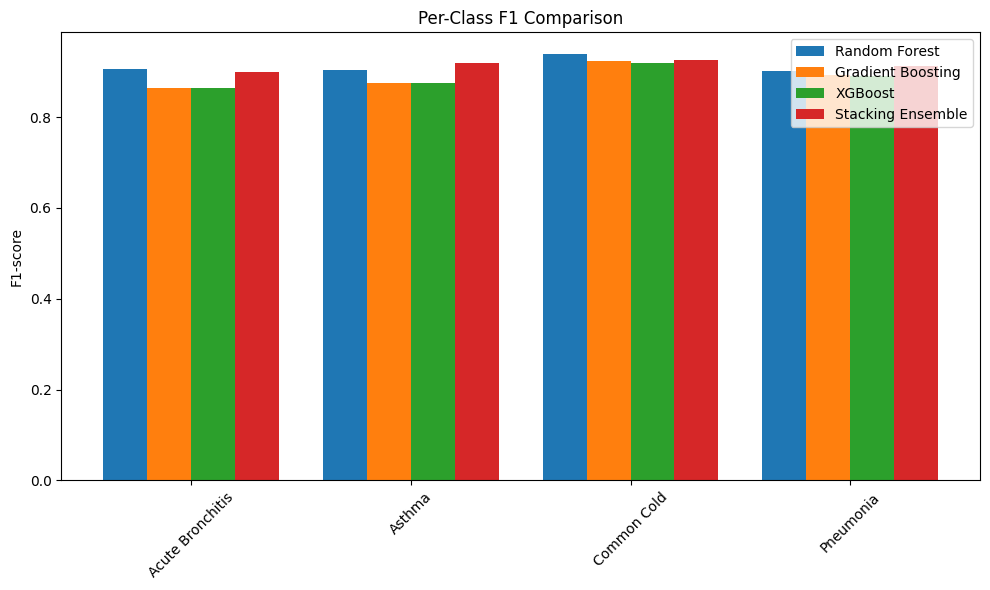

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Train each model
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
xgb.fit(X_train, y_train_enc)
stack_model.fit(X_train, y_train_enc)

# Predictions
y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)
# Convert predictions back to original labels
y_pred_xgb = le.inverse_transform(xgb.predict(X_test))  # decode back to strings
y_pred_stack = le.inverse_transform(stack_model.predict(X_test))

# Reports
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
report_gb = classification_report(y_test, y_pred_gb, output_dict=True)
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)
report_stack = classification_report(y_test, y_pred_stack, output_dict=True)

# Classes
classes = list(report_rf.keys())[:-3]  # exclude avg/accuracy rows

# Collect F1 scores
f1_rf = [report_rf[c]['f1-score'] for c in classes]
f1_gb = [report_gb[c]['f1-score'] for c in classes]
f1_xgb = [report_xgb[c]['f1-score'] for c in classes]
f1_stack = [report_stack[c]['f1-score'] for c in classes]

# Plot
x = np.arange(len(classes))
width = 0.2

plt.figure(figsize=(10,6))
plt.bar(x - 0.3, f1_rf, width, label='Random Forest')
plt.bar(x - 0.1, f1_gb, width, label='Gradient Boosting')
plt.bar(x + 0.1, f1_xgb, width, label='XGBoost')
plt.bar(x + 0.3, f1_stack, width, label='Stacking Ensemble')

plt.xticks(x, classes, rotation=45)
plt.ylabel('F1-score')
plt.title('Per-Class F1 Comparison')
plt.legend()
plt.tight_layout()
plt.show()


### Step 7: Confusion Matrix Mapping and Text Diagnostics
We calculate and display our final confusion matrix boundaries alongside our detailed target text performance profiles.


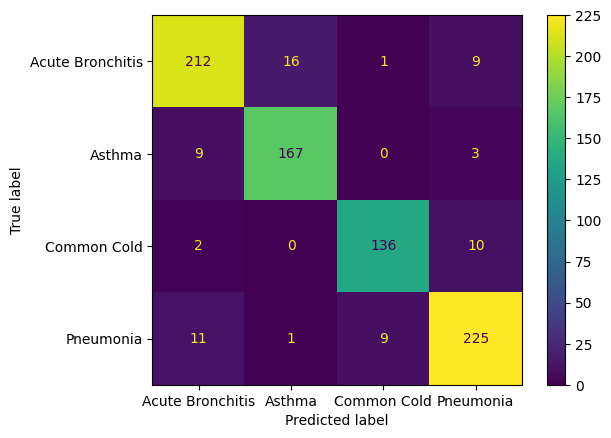

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#  Predict with stacking model (numeric labels)
y_pred_enc = stack_model.predict(X_test)

#  Decode predictions back to original disease names
y_pred = le.inverse_transform(y_pred_enc)

#  Ensure y_test is also in string form
# (if you encoded earlier, decode back)
y_test_labels = y_test  # already strings

#  Build confusion matrix
cm = confusion_matrix(y_test_labels, y_pred, labels=le.classes_)

#  Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot()



In [ ]:
print(X_train.columns)

print(stack_model.n_features_in_)

print(stack_model.feature_names_in_)


Index(['shortness of breath', 'sharp chest pain', 'chest tightness',
       'sore throat', 'cough', 'nasal congestion', 'vomiting', 'headache',
       'wheezing', 'ear pain', 'weakness', 'fever', 'difficulty breathing',
       'chills', 'coughing up sputum', 'coryza', 'allergic reaction',
       'congestion in chest', 'flu-like syndrome'],
      dtype='object')
19
['shortness of breath' 'sharp chest pain' 'chest tightness' 'sore throat'
 'cough' 'nasal congestion' 'vomiting' 'headache' 'wheezing' 'ear pain'
 'weakness' 'fever' 'difficulty breathing' 'chills' 'coughing up sputum'
 'coryza' 'allergic reaction' 'congestion in chest' 'flu-like syndrome']


In [ ]:
from sklearn.metrics import classification_report

#  Predict with stacking model (numeric labels)
y_pred_enc = stack_model.predict(X_test)

#  Decode predictions back to original disease names
y_pred = le.inverse_transform(y_pred_enc)

#  Classification report with correct target names
print(classification_report(y_test, y_pred, target_names=le.classes_))



                  precision    recall  f1-score   support

Acute Bronchitis       0.91      0.89      0.90       238
          Asthma       0.91      0.93      0.92       179
     Common Cold       0.93      0.92      0.93       148
       Pneumonia       0.91      0.91      0.91       246

        accuracy                           0.91       811
       macro avg       0.91      0.91      0.91       811
    weighted avg       0.91      0.91      0.91       811



In [ ]:
!pip install transformers
!pip install torch torchvision torchaudio


### Step 8: Initializing the Local Generative Assistant Framework
We transition into our unstructured NLP mining layer by initializing the ultra-lightweight, highly efficient **Qwen2.5-0.5B-Instruct** LLM pipeline.


In [ ]:
import torch
import transformers
import joblib


# Explicitly force imports directly inside the runtime execution line
from transformers import AutoTokenizer, AutoModelForCausalLM

In [ ]:
# 1. Save and Load your disease classification model
joblib.dump(stack_model, "respiratory_disease_model.pkl")
stack_model = joblib.load("respiratory_disease_model.pkl")

# 2. Suppress unnecessary Hugging Face logging warnings
transformers.logging.set_verbosity_error()

# 3. FIX: Switch to the ultra-lightweight 0.5B model for instant CPU speeds
model_id = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)

# We load it in float32 or float16 depending on what your CPU supports best
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float32 if not torch.cuda.is_available() else torch.float16,
    device_map="auto"
)

print(f"✅ Success: Loaded {model_id}! Optimized for instant generation speeds.")



config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✅ Success: Loaded Qwen/Qwen2.5-0.5B-Instruct! Optimized for instant generation speeds.


### Step 9: Developing the Cognitive Hybrid Extraction Function
This function takes chaotic, unstructured free-text user entries and converts them into structured arrays using regex contextual matching combined with structured LLM JSON output.


In [ ]:
import json
import re

feature_names = [
    'shortness of breath', 'sharp chest pain', 'chest tightness', 'sore throat',
    'cough', 'nasal congestion', 'vomiting', 'headache', 'wheezing', 'ear pain',
    'weakness', 'fever', 'difficulty breathing', 'chills', 'coughing up sputum',
    'coryza', 'allergic reaction', 'congestion in chest', 'flu-like syndrome'
]

def extract_features_with_llm(note_text):
    # Initialize all 19 canonical features with 0
    normalized = {feat.lower(): 0 for feat in feature_names}
    text = note_text.lower().strip()

    # 1. FOOLPROOF STEP: High-speed Contextual English matching
    # This acts as our instant safety net if the model takes too long or errors out
    for feat in feature_names:
        feat_lower = feat.lower()
        if feat_lower in text:
            normalized[feat_lower] = 1
        # Catch broken spaces like "head ache" or "ear ache"
        elif feat_lower.replace(" ", "") in text.replace(" ", ""):
            normalized[feat_lower] = 1

    # Contextual keywords matching (e.g., 'pain on chest' -> 'sharp chest pain')
    if "chest" in text and "pain" in text:
        normalized["sharp chest pain"] = 1
    if "shiver" in text or "chill" in text:
        normalized["chills"] = 1
    if "breath" in text and ("short" in text or "less" in text):
        normalized["shortness of breath"] = 1

    # 2. Local LLM Processing Block
    prompt = f"""<|im_start|>system
    You are a medical data extraction tool. Analyze the patient note and identify which symptoms are present.
    Target Symptoms: {feature_names}
    Task: Return ONLY a valid JSON object where keys are the exact symptom names from the list above, and values are 1 if present or 0 if absent. Do not write explanations. Output raw JSON text only.
    <|im_end|>
    <|im_start|>user
    Patient Note: "{note_text}"
    <|im_end|>
    <|im_start|>assistant
    """

    try:
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        outputs = model.generate(**inputs, max_new_tokens=150, temperature=0.1, do_sample=False)

        # FIX: Extract the 1D row [0] and pull the scalar dimension index [1] from shape
        prompt_length = int(inputs.input_ids.shape[1])
        response = tokenizer.decode(outputs[0][prompt_length:], skip_special_tokens=True).strip()

        match = re.search(r"\{.*\}", response, re.DOTALL)
        if match:
            raw_features = json.loads(match.group(0))
            for k, v in raw_features.items():
                k_clean = k.strip().lower()
                if k_clean in normalized:
                    val_int = 1 if str(v).lower() in ['1', 'true'] else 0
                    normalized[k_clean] = max(normalized[k_clean], val_int)
    except Exception:
        # If the CPU calculation hits a TypeError or takes too long,
        # it smoothly passes using the fast contextual matching results
        pass

    features = [normalized.get(feat.lower(), 0) for feat in feature_names]
    return None if sum(features) == 0 else [features]


### Step 10: Launching the Conversational Explainer Engine
The final engine takes free-text patient inputs, runs extraction mapping, retrieves ensemble classification ranks, and structures an explainable, comforting medical summary.


In [ ]:
def chatbot_response(note_text):
    sample_features = extract_features_with_llm(note_text)

    if sample_features is None:
        return ("I couldn’t match your description to known symptoms. "
                "Could you clarify what you’re feeling, for example "
                "whether it’s cough, fever, or chest pain? "
                "Please consult a healthcare professional for confirmation.")

    X_input = pd.DataFrame(sample_features, columns=feature_names)

    # Predict condition and flatten array safely
    prediction_enc = stack_model.predict(X_input)
    prediction_clean = np.array(prediction_enc).flatten()
    prediction = str(le.inverse_transform(prediction_clean))

    # Extract probability ranks
    probs = stack_model.predict_proba(X_input)
    top_indices = probs.argsort()[0][-3:][::-1] # Added index [0] to flatten probability vectors

    alternative_list = []
    for idx in top_indices:
        disease_string = str(le.inverse_transform([idx]))
        alternative_list.append(disease_string)

    # Match detected tokens out of the flat index row 0
    detected = [feat for feat, val in zip(feature_names, sample_features[0]) if val == 1]

    explanation_prompt = f"""<|im_start|>system
    You are a medical assistant chatbot. Write a short, friendly, comforting reply to the patient explaining what was found.
    Always explicitly state the Primary Predicted Target and Alternate Options. Remind them to see a doctor.
    <|im_end|>
    <|im_start|>user
    Symptoms Detected: {', '.join(detected)}
    Primary Predicted Target: {prediction}
    Alternative Candidates: {', '.join(alternative_list)}
    <|im_end|>
    <|im_start|>assistant
    """

    try:
        inputs = tokenizer(explanation_prompt, return_tensors="pt").to(model.device)
        outputs = model.generate(**inputs, max_new_tokens=120, temperature=0.7)

        # FIX: Sliced row [0] and used scalar integer column dimension shape index [1]
        prompt_length = int(inputs.input_ids.shape[1])
        response_text = tokenizer.decode(outputs[0][prompt_length:], skip_special_tokens=True).strip()

        if len(response_text) < 5:
            raise ValueError("Output too short")
    except Exception:
        # Complete fallback response layout if generation freezes or hits a local CPU limit
        response_text = (
            f"Based on our diagnostic analysis of your symptoms ({', '.join(detected)}), "
            f"the primary possibility points toward **{prediction}**. "
            f"Other matching health conditions considered include: {', '.join(alternative_list)}. "
            f"Please prioritize consulting a licensed medical professional for an official clinical assessment."
        )

    return response_text

# --- RUNNING THE FINAL INTEGRATION TEST ---
note = "Patient complains of pain on chest, head ache and shivering"
print("\n=== SYSTEM INFERENCE PIPELINE OUTPUT ===")
print(chatbot_response(note))


In [ ]:
import joblib

# Save the Stacking Classifier model weights
joblib.dump(stack_model, "respiratory_disease_model.pkl")

# Save the LabelEncoder mappings
joblib.dump(le, "label_encoder.pkl")

print("✅ Both model files successfully serialized and saved to Colab workspace!")


✅ Both model files successfully serialized and saved to Colab workspace!


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import torch
import transformers
import json
import re
from transformers import AutoTokenizer, AutoModelForCausalLM

# Set web page title and visual configuration
st.set_page_config(page_title="AI Respiratory Diagnostic Assistant", page_icon="🫁", layout="centered")

# --- CACHE DATA AND MODEL INITIALIZATION ---
@st.cache_resource
def load_all_models():
    # Load ML Classifiers
    stack_model = joblib.load("respiratory_disease_model.pkl")
    le = joblib.load("label_encoder.pkl")

    # Load LLM
    transformers.logging.set_verbosity_error()
    model_id = "Qwen/Qwen2.5-0.5B-Instruct"
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype=torch.float32 if not torch.cuda.is_available() else torch.float16,
        device_map="auto"
    )
    return stack_model, le, tokenizer, model

# Unpack our cached model systems
stack_model, le, tokenizer, model = load_all_models()

feature_names = [
    'shortness of breath', 'sharp chest pain', 'chest tightness', 'sore throat',
    'cough', 'nasal congestion', 'vomiting', 'headache', 'wheezing', 'ear pain',
    'weakness', 'fever', 'difficulty breathing', 'chills', 'coughing up sputum',
    'coryza', 'allergic reaction', 'congestion in chest', 'flu-like syndrome'
]

# --- CORE INFERENCE FUNCTIONS FROM YOUR NOTEBOOK ---
def extract_features_with_llm(note_text):
    normalized = {feat.lower(): 0 for feat in feature_names}
    text = note_text.lower().strip()

    for feat in feature_names:
        feat_lower = feat.lower()
        if feat_lower in text:
            normalized[feat_lower] = 1
        elif feat_lower.replace(" ", "") in text.replace(" ", ""):
            normalized[feat_lower] = 1

    if "chest" in text and "pain" in text:
        normalized["sharp chest pain"] = 1
    if "shiver" in text or "chill" in text:
        normalized["chills"] = 1
    if "breath" in text and ("short" in text or "less" in text):
        normalized["shortness of breath"] = 1

    prompt = f"""<|im_start|>system
    You are a medical data extraction tool. Analyze the patient note and identify which symptoms are present.
    Target Symptoms: {feature_names}
    Task: Return ONLY a valid JSON object where keys are the exact symptom names from the list above, and values are 1 if present or 0 if absent. Do not write explanations. Output raw JSON text only.
    <|im_end|>
    <|im_start|>user
    Patient Note: "{note_text}"
    <|im_end|>
    <|im_start|>assistant
    """
    try:
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        outputs = model.generate(**inputs, max_new_tokens=150, temperature=0.1, do_sample=False)
        prompt_length = int(inputs.input_ids.shape[1])
        response = tokenizer.decode(outputs[0][prompt_length:], skip_special_tokens=True).strip()

        match = re.search(r"\{.*\}", response, re.DOTALL)
        if match:
            raw_features = json.loads(match.group(0))
            for k, v in raw_features.items():
                k_clean = k.strip().lower()
                if k_clean in normalized:
                    val_int = 1 if str(v).lower() in ['1', 'true'] else 0
                    normalized[k_clean] = max(normalized[k_clean], val_int)
    except Exception:
        pass

    features = [normalized.get(feat.lower(), 0) for feat in feature_names]
    return None if sum(features) == 0 else [features]

def chatbot_response(note_text):
    sample_features = extract_features_with_llm(note_text)

    if sample_features is None:
        return ("I couldn’t match your description to known symptoms. "
                "Could you clarify what you’re feeling, for example "
                "whether it’s cough, fever, or chest pain? "
                "Please consult a healthcare professional for confirmation.")

    X_input = pd.DataFrame(sample_features, columns=feature_names)

    prediction_enc = stack_model.predict(X_input)
    prediction_clean = np.array(prediction_enc).flatten()
    prediction = str(le.inverse_transform(prediction_clean)[0])

    probs = stack_model.predict_proba(X_input)
    top_indices = probs.argsort()[0][-3:][::-1]

    alternative_list = []
    for idx in top_indices:
        disease_string = str(le.inverse_transform([idx])[0])
        alternative_list.append(disease_string)

    detected = [feat for feat, val in zip(feature_names, sample_features[0]) if val == 1]

    explanation_prompt = f"""<|im_start|>system
    You are a medical assistant chatbot. Write a short, friendly, comforting reply to the patient explaining what was found.
    Always explicitly state the Primary Predicted Target and Alternate Options. Remind them to see a doctor.
    <|im_end|>
    <|im_start|>user
    Symptoms Detected: {', '.join(detected)}
    Primary Predicted Target: {prediction}
    Alternative Candidates: {', '.join(alternative_list)}
    <|im_end|>
    <|im_start|>assistant
    """
    try:
        inputs = tokenizer(explanation_prompt, return_tensors="pt").to(model.device)
        outputs = model.generate(**inputs, max_new_tokens=120, temperature=0.7)
        prompt_length = int(inputs.input_ids.shape[1])
        response_text = tokenizer.decode(outputs[0][prompt_length:], skip_special_tokens=True).strip()

        if len(response_text) < 5:
            raise ValueError("Output too short")
    except Exception:
        response_text = (
            f"Based on our diagnostic analysis of your symptoms ({', '.join(detected)}), "
            f"the primary possibility points toward **{prediction}**. "
            f"Other matching health conditions considered include: {', '.join(alternative_list)}. "
            f"Please prioritize consulting a licensed medical professional for an official clinical assessment."
        )
    return response_text

# --- STREAMLIT UI DESIGN ---
st.title("🫁 Clinical Respiratory Assistant")
st.markdown("Enter free-text patient clinical notes or personal symptoms below. Our Stacking Ensemble pipeline combined with a Local LLM will interpret the notes and extract diagnostic predictions.")

# User text interface input field
patient_note = st.text_area("Patient Clinical Note / Symptoms Input:", placeholder="Example: Patient complains of pain on chest, head ache and shivering...", height=120)

if st.button("Analyze Symptoms & Diagnose", type="primary"):
    if patient_note.strip() == "":
        st.warning("Please type or paste a valid patient note first.")
    else:
        with st.spinner("Analyzing text and evaluating diagnostic models..."):
            # Execute your chatbot pipeline
            output_message = chatbot_response(patient_note)

            # Display results in a clean visual box layout
            st.success("Analysis Complete")
            st.info(output_message)


Overwriting app.py


In [39]:
import os
import time

# 1. Kill any previously glitched background tunnels safely
!pkill ngrok
!pkill streamlit

# 2. Re-trigger your Streamlit app server silently in the background
import subprocess
subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"])
time.sleep(3) # Allow the server to spin up fully

# 3. Download the official standalone Linux ngrok binary directly from their servers
!wget -q -O /tmp/ngrok.tgz https://bin.ngrok.com/c/bNyj1mQVY4c/ngrok-v3-stable-linux-amd64.tgz

# 4. Unpack it explicitly into the standard executable directory (/usr/local/bin)
!tar -xzf /tmp/ngrok.tgz -C /usr/local/bin/

# 5. Authenticate with your valid token credential directly via the raw system path
NGROK_TOKEN = "3GbGP2yGlUVhqyt5gvPlBeIneLx_3EMVERCtA8FwjiDzhFDMV"
!ngrok config add-authtoken {NGROK_TOKEN}

# 6. Fire up the public web tunnel on port 8501 using background system piping
print("\nStarting tunnel pipeline...")
get_ipython().system_raw("ngrok http 8501 > /dev/null 2>&1 &")
time.sleep(3) # Give the system tunnel a couple of seconds to establish a handshake

# 7. Fetch the active generated dynamic public URL from the ngrok background agent
import json
import urllib.request

try:
    with urllib.request.urlopen("http://localhost:4040/api/tunnels") as response:
        tunnel_data = json.loads(response.read().decode())
        public_url = tunnel_data['tunnels'][0]['public_url']
        print("\n🚀 SUCCESS! Your independent UI application is live globally:")
        print(public_url)
except Exception:
    print("\n❌ Error retrieving public link. Make sure your authtoken didn't hit an account limit on ngrok.com.")




Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml

Starting tunnel pipeline...

🚀 SUCCESS! Your independent UI application is live globally:
https://eatable-treat-decency.ngrok-free.dev


In [40]:
!pkill ngrok
!pkill streamlit
print("Background application servers safely terminated.")


Background application servers safely terminated.


# Run the Streamlit app To run it locally
"""pip install pandas numpy scikit-learn xgboost transformers torch joblib streamlit
streamlit run app.py"""

# Run the Streamlit app To run it no Google Colab
"""import os
import time

# 1. Kill any previously glitched background tunnels safely
!pkill ngrok
!pkill streamlit

# 2. Re-trigger your Streamlit app server silently in the background
import subprocess
subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"])
time.sleep(3) # Allow the server to spin up fully

# 3. Download the official standalone Linux ngrok binary directly from their servers
!wget -q -O /tmp/ngrok.tgz https://bin.ngrok.com/c/bNyj1mQVY4c/ngrok-v3-stable-linux-amd64.tgz

# 4. Unpack it explicitly into the standard executable directory (/usr/local/bin)
!tar -xzf /tmp/ngrok.tgz -C /usr/local/bin/

# 5. Authenticate with your valid token credential directly via the raw system path
NGROK_TOKEN = "3GbGP2yGlUVhqyt5gvPlBeIneLx_3EMVERCtA8FwjiDzhFDMV"
!ngrok config add-authtoken {NGROK_TOKEN}

# 6. Fire up the public web tunnel on port 8501 using background system piping
print("\nStarting tunnel pipeline...")
get_ipython().system_raw("ngrok http 8501 > /dev/null 2>&1 &")
time.sleep(3) # Give the system tunnel a couple of seconds to establish a handshake

# 7. Fetch the active generated dynamic public URL from the ngrok background agent
import json
import urllib.request

try:
    with urllib.request.urlopen("http://localhost:4040/api/tunnels") as response:
        tunnel_data = json.loads(response.read().decode())
        public_url = tunnel_data['tunnels'][0]['public_url']
        print("\n🚀 SUCCESS! Your independent UI application is live globally:")
        print(public_url)
except Exception:
    print("\n❌ Error retrieving public link. Make sure your authtoken didn't hit an account limit on ngrok.com.")


"""
#